# StatsForecast Adapter — AirPassengers Example

This notebook shows how to use `StatsForecastAdapter` with the classic
AirPassengers dataset (144 monthly observations, 1949–1960).

We demonstrate:
1. Fitting a model and creating the adapter
2. Cross-validation for conformal calibration
3. Split conformal prediction with calibrated intervals
4. Quantile forecasts from the model
5. Refitting on extended data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsforecast import StatsForecast
from statsforecast.models import AutoETS
from statsforecast.utils import AirPassengersDF

from conformal_ts.adapters.statsforecast import StatsForecastAdapter
from conformal_ts.methods.split import SplitConformal

/Users/marcopeix/dev/conformal-ts/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load data and fit the model

AirPassengers uses month-end timestamps, so `freq="ME"`. We fit an
`AutoETS` model with `season_length=12`.

In [2]:
HORIZON = 12
FREQ = "ME"
SEASON_LENGTH = 12

df = AirPassengersDF.copy()
df["unique_id"] = df["unique_id"].astype(str)

print(f"Shape: {df.shape}")
print(f"Date range: {df['ds'].min()} to {df['ds'].max()}")
df.head()

Shape: (144, 3)
Date range: 1949-01-31 00:00:00 to 1960-12-31 00:00:00


,unique_id,ds,y
0,1.0,1949-01-31,112.0
1,1.0,1949-02-28,118.0
2,1.0,1949-03-31,132.0
3,1.0,1949-04-30,129.0
4,1.0,1949-05-31,121.0


In [3]:
sf = StatsForecast(models=[AutoETS(season_length=SEASON_LENGTH)], freq=FREQ)
sf.fit(df)

adapter = StatsForecastAdapter(
    sf=sf,
    train_df=df,
    horizon=HORIZON,
    freq=FREQ,
    model_name="AutoETS",
)

print(f"Adapter: n_series={adapter.n_series}, horizon={adapter.horizon}")
print(f"Common range: {adapter._common_start} to {adapter._common_end}")

Adapter: n_series=1, horizon=12
Common range: 1949-01-31 00:00:00 to 1960-12-31 00:00:00


## 2. Point forecast

`predict` returns shape `(n_series, 1, horizon)` — here `(1, 1, 12)`.

In [4]:
full_history = adapter._df_to_panel(df, "y")  # (1, 144)
forecast = adapter.predict(full_history)

print(f"Forecast shape: {forecast.shape}")
print(f"Next 12 months: {forecast[0, 0].round(1)}")

Forecast shape: (1, 1, 12)
Next 12 months: [442.4 428.3 493.  477.4 477.6 535.9 600.8 594.8 513.7 448.2 390.3 435.7]


## 3. Cross-validation for conformal calibration

We use the adapter's built-in cross-validation to generate calibration
data — 24 rolling windows stepped by 1 month. This produces matched
`(predictions, truths)` arrays that `SplitConformal.calibrate` expects.

In [5]:
N_WINDOWS = 24
STEP_SIZE = 1

cv_preds, cv_truths = adapter.cross_validate(n_windows=N_WINDOWS, step_size=STEP_SIZE, refit=False)

print(f"CV predictions shape: {cv_preds.shape}")  # (1, 24, 12)
print(f"CV truths shape:      {cv_truths.shape}")

CV predictions shape: (1, 24, 12)
CV truths shape:      (1, 24, 12)


## 4. Split conformal prediction

We can calibrate `SplitConformal` directly on the adapter — passing
`n_windows` (and optionally `step_size` / `refit`) makes the method
dispatch to `forecaster.cross_validate(...)` under the hood, which is
**one** native StatsForecast call. The slower fallback path (one
`predict_batch` call per window) is reserved for adapters that don't
implement `SupportsCrossValidation`.

In [6]:
ALPHA = 0.1  # 90% prediction intervals

method = SplitConformal(adapter, alpha=ALPHA)
cal_result = method.calibrate(n_windows=N_WINDOWS, step_size=STEP_SIZE)

print(f"Calibration samples: {cal_result.n_calibration_samples}")
print(f"Score quantile shape: {cal_result.score_quantile.shape}")
print(f"Score quantile per horizon step:\n{cal_result.score_quantile[0].round(1)}")

Calibration samples: 24
Score quantile shape: (1, 12)
Score quantile per horizon step:
[44.1 55.  68.2 75.6 79.7 75.4 79.6 79.2 84.8 86.6 85.8 80.7]


### What is the score quantile?

The **score quantile** is the core output of conformal calibration. Here's how it works:

1. For each of the 24 cross-validation windows, the model forecasts 12 months ahead and we compute the **absolute residual** `|truth - prediction|` at every horizon step.
2. We then take the empirical quantile of these residuals at level `ceil((1 - alpha) * (n + 1)) / n` — a finite-sample-corrected version of the `(1 - alpha)` quantile. This is computed **independently for each horizon step**.
3. The result is a vector of 12 values (one per horizon step). Each value is the threshold below which ~90% of the calibration residuals fell at that step.

The prediction interval at each horizon step `h` is then simply:

    [forecast(h) - q(h),  forecast(h) + q(h)]

Notice the score quantile **grows with the horizon** (from ~40 at h=1 to ~88 at h=11). This reflects the natural increase in forecast uncertainty further into the future — the conformal method learns this from the calibration residuals without any distributional assumptions.

In [7]:
# Produce a conformal prediction on the full history
result = method.predict(full_history)

print(f"Point forecast shape: {result.point.shape}")
print(f"Interval shape:       {result.interval.shape}")
print(f"Alpha:                {result.alpha}")
print()

# Display as a table
forecast_dates = pd.date_range(start=adapter._common_end, periods=HORIZON + 1, freq=FREQ)[1:]

summary = pd.DataFrame(
    {
        "date": forecast_dates,
        "lower_90": result.interval[0, 0, :, 0].round(1),
        "point": result.point[0, 0].round(1),
        "upper_90": result.interval[0, 0, :, 1].round(1),
    }
)
summary["width"] = (summary["upper_90"] - summary["lower_90"]).round(1)
summary

Point forecast shape: (1, 1, 12)
Interval shape:       (1, 1, 12, 2)
Alpha:                0.1



,date,lower_90,point,upper_90,width
0,1961-01-31,398.3,442.4,486.4,88.1
1,1961-02-28,373.3,428.3,483.3,110.0
2,1961-03-31,424.7,493.0,561.2,136.5
3,1961-04-30,401.8,477.4,552.9,151.1
4,1961-05-31,397.9,477.6,557.3,159.4
5,1961-06-30,460.5,535.9,611.2,150.7
6,1961-07-31,521.2,600.8,680.4,159.2
7,1961-08-31,515.5,594.8,674.0,158.5
8,1961-09-30,428.9,513.7,598.5,169.6
9,1961-10-31,361.7,448.2,534.8,173.1


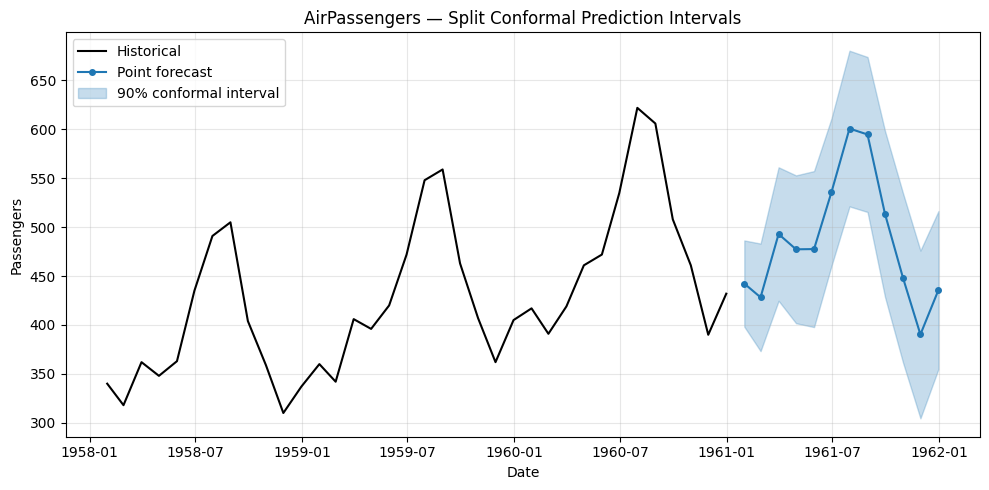

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

# Plot historical data
hist_dates = df["ds"].values
hist_values = full_history[0]
ax.plot(hist_dates[-36:], hist_values[-36:], color="black", label="Historical")

# Plot forecast and conformal interval
ax.plot(
    forecast_dates,
    result.point[0, 0],
    color="tab:blue",
    marker="o",
    markersize=4,
    label="Point forecast",
)
ax.fill_between(
    forecast_dates,
    result.interval[0, 0, :, 0],
    result.interval[0, 0, :, 1],
    alpha=0.25,
    color="tab:blue",
    label=f"{1 - ALPHA:.0%} conformal interval",
)

ax.set_title("AirPassengers — Split Conformal Prediction Intervals")
ax.set_xlabel("Date")
ax.set_ylabel("Passengers")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## 5. Quantile forecasts

The adapter also exposes `predict_quantiles` for model-native quantile
forecasts. Quantiles must be passed as symmetric pairs around 0.5.

In [9]:
quantiles = np.array([0.05, 0.25, 0.75, 0.95])
q_forecast = adapter.predict_quantiles(full_history, quantiles)

print(f"Quantile forecast shape: {q_forecast.shape}")  # (1, 4, 12)

q_df = pd.DataFrame(
    {
        "date": forecast_dates,
        "q05": q_forecast[0, 0].round(1),
        "q25": q_forecast[0, 1].round(1),
        "q75": q_forecast[0, 2].round(1),
        "q95": q_forecast[0, 3].round(1),
    }
)
q_df

Quantile forecast shape: (1, 4, 12)


,date,q05,q25,q75,q95
0,1961-01-31,406.1,427.5,457.2,478.7
1,1961-02-28,389.8,412.5,444.1,466.8
2,1961-03-31,451.7,476.1,509.9,534.2
3,1961-04-30,433.7,459.5,495.3,521.0
4,1961-05-31,431.6,458.8,496.5,523.6
5,1961-06-30,487.2,515.9,555.8,584.6
6,1961-07-31,548.9,579.5,622.1,652.8
7,1961-08-31,539.9,572.2,617.3,649.7
8,1961-09-30,456.7,490.3,537.1,570.7
9,1961-10-31,389.6,424.2,472.3,506.8


### Conformal vs model-native intervals

The conformal interval (blue) has a finite-sample coverage guarantee — it will
contain the true value at least 90% of the time, regardless of whether the
model's distributional assumptions are correct. The model-native quantile
interval (orange) relies on the ETS error distribution being well-specified.

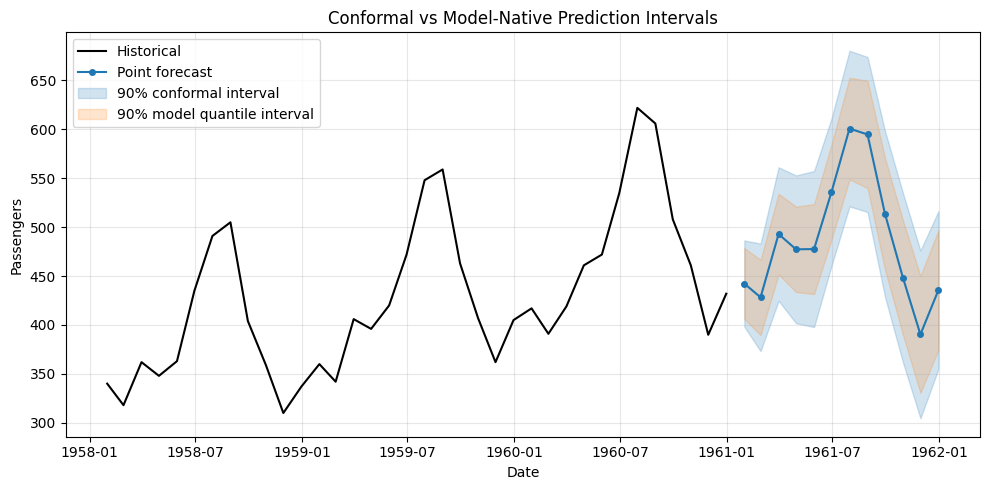

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

# Historical
ax.plot(hist_dates[-36:], hist_values[-36:], color="black", label="Historical")

# Point forecast
ax.plot(
    forecast_dates,
    result.point[0, 0],
    color="tab:blue",
    marker="o",
    markersize=4,
    label="Point forecast",
)

# Conformal 90% interval
ax.fill_between(
    forecast_dates,
    result.interval[0, 0, :, 0],
    result.interval[0, 0, :, 1],
    alpha=0.2,
    color="tab:blue",
    label="90% conformal interval",
)

# Model-native 90% quantile interval (q05–q95)
ax.fill_between(
    forecast_dates,
    q_forecast[0, 0],  # q05
    q_forecast[0, 3],  # q95
    alpha=0.2,
    color="tab:orange",
    label="90% model quantile interval",
)

ax.set_title("Conformal vs Model-Native Prediction Intervals")
ax.set_xlabel("Date")
ax.set_ylabel("Passengers")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## 6. Refit on extended data

Simulating the arrival of 12 new months of data. After `refit`, the
adapter's end timestamp advances and forecasts anchor at the new end.

In [11]:
print(f"End before refit: {adapter._common_end}")

# Simulate 12 new observations (repeat the last year with some noise)
rng = np.random.default_rng(42)
last_year = full_history[:, -12:]
new_obs = last_year * (1 + 0.05 * rng.standard_normal(last_year.shape))
extended_history = np.concatenate([full_history, new_obs], axis=1)

print(f"Original history: {full_history.shape[1]} months")
print(f"Extended history: {extended_history.shape[1]} months")

adapter.refit(extended_history)
print(f"End after refit:  {adapter._common_end}")

# Forecast from the new end
new_forecast = adapter.predict(extended_history)
print(f"\nForecast from extended data (first 3 months): {new_forecast[0, 0, :3].round(1)}")

End before refit: 1960-12-31 00:00:00
Original history: 144 months
Extended history: 156 months
End after refit:  1961-12-31 00:00:00

Forecast from extended data (first 3 months): [431.  389.  453.6]
